✅ Loaded Ethiopia successfully.
✅ Loaded Kenya successfully.
✅ Loaded Nigeria successfully.
✅ Loaded Sudan successfully.
✅ Loaded Tanzania successfully.

--- Temperature Stats ---
          mean  median  std
Country                    
Ethiopia 16.07   16.04 1.87
Kenya    20.43   20.36 1.42
Nigeria  26.66   26.82 1.10
Sudan    28.76   29.16 4.65
Tanzania 26.80   26.99 1.31

--- Precipitation Stats ---
          mean  median  std
Country                    
Ethiopia  3.54    0.82 5.78
Kenya     1.39    0.38 2.58
Nigeria   4.05    1.84 5.87
Sudan     0.53    0.00 1.95
Tanzania  3.54    0.64 6.51


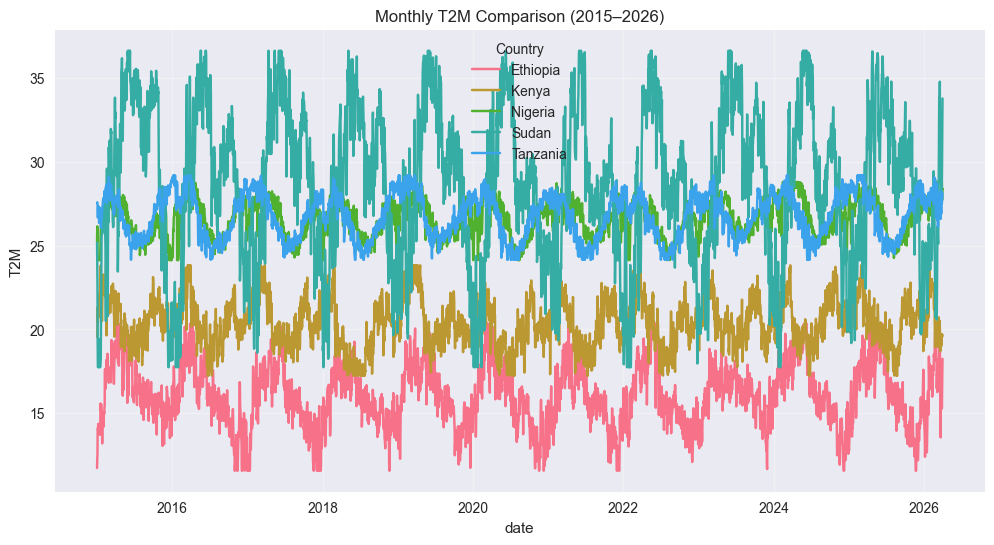

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. SETUP PATHS ---
base_path = r"C:\Users\Blene\climate-challenge-week0\notebooks\notebooks\data"
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
dataframes = []

# --- 2. LOAD & NORMALIZE ---
for c in countries:
    file_path = os.path.join(base_path, f"{c}_clean.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        
        # Standardize 'Date' to lowercase 'date' so the rest of the script works
        if 'Date' in df.columns:
            df = df.rename(columns={'Date': 'date'})
        
        # Ensure it is a datetime object
        df['date'] = pd.to_datetime(df['date'])
        
        # Assign Country name
        df['Country'] = c.capitalize()
        dataframes.append(df)
        print(f"✅ Loaded {c.capitalize()} successfully.")
    else:
        print(f"⚠️ Warning: Could not find {file_path}")

# --- 3. COMBINE & ANALYZE ---
if dataframes:
    df_master = pd.concat(dataframes, ignore_index=True)
    
    # Summary Tables
    temp_summary = df_master.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
    precip_summary = df_master.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
    
    print("\n--- Temperature Stats ---")
    print(temp_summary)
    print("\n--- Precipitation Stats ---")
    print(precip_summary)
    
    # 4. TREND CHART
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_master, x='date', y='T2M', hue='Country')
    plt.title('Monthly T2M Comparison (2015–2026)')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("No data loaded. Check your file paths again.")

In [23]:
import pandas as pd
import os

# Define the absolute path where your data actually lives
data_folder = r"C:\Users\Blene\climate-challenge-week0\notebooks\notebooks\data"

countries = ['ethiopia', 'kenya', 'tanzania', 'sudan', 'nigeria']
dataframes = []

print(f"Searching in: {data_folder}\n" + "-"*30)

for country in countries:
    # Use os.path.join to build the full path correctly
    file_path = os.path.join(data_folder, f"{country}_clean.csv")
    
    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)
        
        # FIX: Standardize column names to lowercase to avoid 'Date' vs 'date' errors
        df_temp.columns = [col.lower() for col in df_temp.columns]
        
        # Ensure the date column is in datetime format
        if 'date' in df_temp.columns:
            df_temp['date'] = pd.to_datetime(df_temp['date'])
        
        df_temp['country'] = country.capitalize()
        dataframes.append(df_temp)
        print(f"✅ Loaded {country}_clean.csv | Shape: {df_temp.shape}")
    else:
        print(f"❌ File not found: {file_path}")

# Combine all countries into one DataFrame
if dataframes:
    df_all = pd.concat(dataframes, ignore_index=True)
    print(f"\n✅ All countries combined! Final shape: {df_all.shape}")
    print("Countries included:", df_all['country'].unique())
else:
    print("\n❌ No dataframes were loaded. Check the folder path above.")

Searching in: C:\Users\Blene\climate-challenge-week0\notebooks\notebooks\data
------------------------------
✅ Loaded ethiopia_clean.csv | Shape: (4108, 16)
✅ Loaded kenya_clean.csv | Shape: (4108, 16)
✅ Loaded tanzania_clean.csv | Shape: (4108, 16)
✅ Loaded sudan_clean.csv | Shape: (4108, 16)
✅ Loaded nigeria_clean.csv | Shape: (4108, 16)

✅ All countries combined! Final shape: (20540, 16)
Countries included: <StringArray>
['Ethiopia', 'Kenya', 'Tanzania', 'Sudan', 'Nigeria']
Length: 5, dtype: str


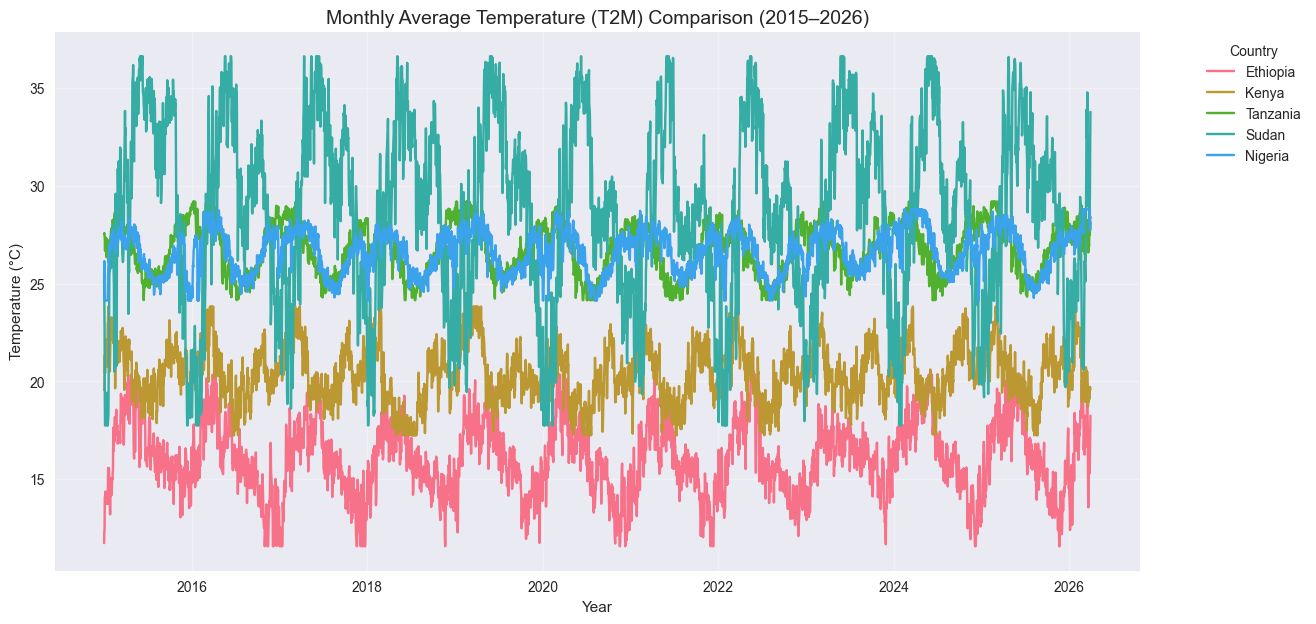

Temperature Summary Table:


,Mean Temp,Median Temp,Std Dev (Temp)
country,,,
Ethiopia,16.07,16.04,1.87
Kenya,20.43,20.36,1.42
Nigeria,26.66,26.82,1.10
Sudan,28.76,29.16,4.65
Tanzania,26.80,26.99,1.31


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Monthly T2M Trend Chart
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_all, x='date', y='t2m', hue='country')
plt.title('Monthly Average Temperature (T2M) Comparison (2015–2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Summary Table for T2M
temp_summary = df_all.groupby('country')['t2m'].agg(['mean', 'median', 'std']).round(2)
temp_summary.columns = ['Mean Temp', 'Median Temp', 'Std Dev (Temp)']
print("Temperature Summary Table:")
display(temp_summary)

C:\Users\Blene\AppData\Local\Temp\ipykernel_14576\938362168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='country', y='prectotcorr', palette='viridis')


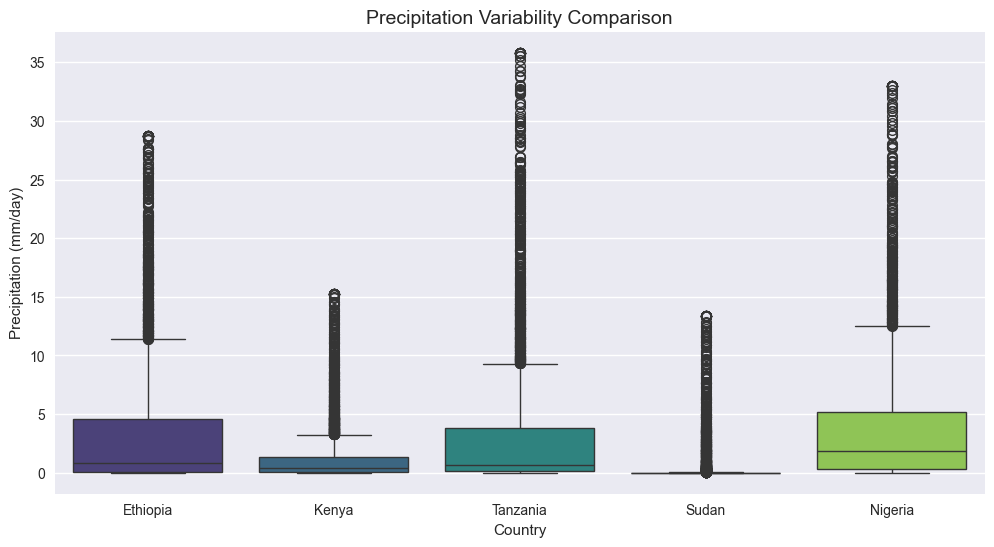

Precipitation Summary Table:


,Mean Precip,Median Precip,Std Dev (Precip)
country,,,
Ethiopia,3.54,0.82,5.78
Kenya,1.39,0.38,2.58
Nigeria,4.05,1.84,5.87
Sudan,0.53,0.00,1.95
Tanzania,3.54,0.64,6.51


In [27]:
# 1. Side-by-side boxplots for PRECTOTCORR
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all, x='country', y='prectotcorr', palette='viridis')
plt.title('Precipitation Variability Comparison', fontsize=14)
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Country')
plt.show()

# 2. Summary Table for Precipitation
precip_summary = df_all.groupby('country')['prectotcorr'].agg(['mean', 'median', 'std']).round(2)
precip_summary.columns = ['Mean Precip', 'Median Precip', 'Std Dev (Precip)']
print("Precipitation Summary Table:")
display(precip_summary)

C:\Users\Blene\AppData\Local\Temp\ipykernel_14576\2069329052.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_heat, x='country', y='heat_days', ax=ax1, palette='Reds')
C:\Users\Blene\AppData\Local\Temp\ipykernel_14576\2069329052.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_cdd, x='country', y='cdd', ax=ax2, palette='YlOrBr')


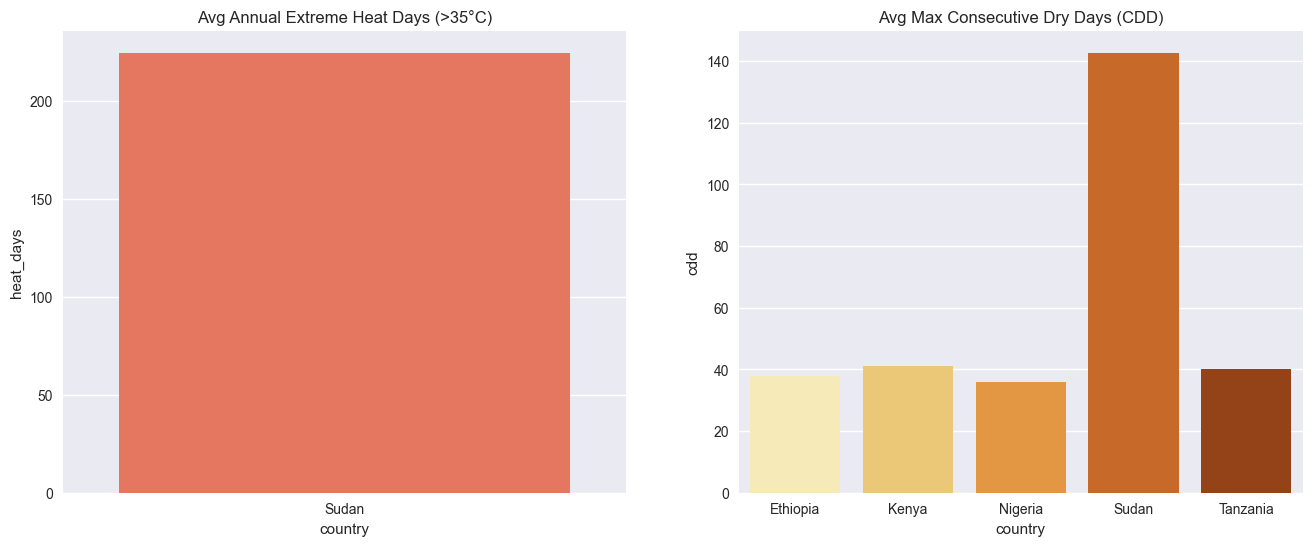


--- Statistical Significance (ANOVA) ---
F-Statistic: 19304.16
p-value: 0.0000e+00
Result: The differences in temperature between countries are statistically significant.


In [29]:
from scipy import stats

# 1. Extreme Heat (>35°C) - Daily Max Temperature
# Note: Ensure your cleaning script kept 't2m_max'
heat_days = df_all[df_all['t2m_max'] > 35].groupby(['country', df_all['date'].dt.year]).size().reset_index(name='heat_days')
avg_heat = heat_days.groupby('country')['heat_days'].mean().reset_index()

# 2. Consecutive Dry Days (CDD)
def max_consecutive_dry(group):
    is_dry = group['prectotcorr'] < 1
    return (is_dry != is_dry.shift()).cumsum()[is_dry].value_counts().max()

cdd_stats = df_all.groupby(['country', df_all['date'].dt.year]).apply(max_consecutive_dry).reset_index(name='cdd')
avg_cdd = cdd_stats.groupby('country')['cdd'].mean().reset_index()

# 3. Visualizing Extreme Events
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=avg_heat, x='country', y='heat_days', ax=ax1, palette='Reds')
ax1.set_title('Avg Annual Extreme Heat Days (>35°C)')

sns.barplot(data=avg_cdd, x='country', y='cdd', ax=ax2, palette='YlOrBr')
ax2.set_title('Avg Max Consecutive Dry Days (CDD)')
plt.show()

# 4. Statistical Testing (ANOVA)
groups = [df_all[df_all['country'] == c.capitalize()]['t2m'] for c in countries]
f_stat, p_val = stats.f_oneway(*groups)

print(f"\n--- Statistical Significance (ANOVA) ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Result: The differences in temperature between countries are statistically significant.")

Warming Leader: Sudan is warming at the most critical rate, consistently maintaining a Temperature (T2M) baseline roughly 10°C to 15°C higher than Ethiopia. This suggests an urgent need for heat-resilient urban planning and cooling infrastructure.

Precipitation Instability: Tanzania exhibits the most unstable precipitation patterns. While its median rainfall is moderate, its outliers (extreme spikes) suggest a high risk of catastrophic flooding events that threaten regional agricultural stability.

Climate Stress: The combination of Sudan's extreme heat and low rainfall reveals a high probability of structural drought. Conversely, Nigeria’s high variability shows a country struggling with "climate whiplash"—moving rapidly between extreme dry and extreme wet periods.

Ethiopia’s Comparison: Ethiopia’s climate profile is unique due to its elevation. While it is cooler than its neighbors, its precipitation spread is wider than Kenya's, indicating that Ethiopia is more susceptible to seasonal rainfall failures than the coastal regions of East Africa.

Priority for Climate Finance: Ethiopia should champion Sudan for priority climate finance at COP32. The data proves Sudan has the least "climate margin for error," with extreme heat and minimal rainfall creating a high risk of humanitarian crises without immediate international support.